# Gomi — Full Training Pipeline

**Step 1:** Fine-tune DistilBERT on combined OpenReview dataset (2k human + 5k auto-labeled)  
**Step 2:** Train Logistic Regression risk fusion model on DeepJIT + ApacheJIT  
**Step 3:** Push both models to Hugging Face Hub

> ⚡ Make sure **Runtime → Change runtime type → T4 GPU** is selected before running.

---
**Hugging Face repos:**
- Dataset: `GitRatBCSAD/gomi-datasets`
- Sentiment model: `GitRatBCSAD/gomi-sentiment`
- Risk model: `GitRatBCSAD/gomi-risk`

In [1]:
# ── 0. Check GPU ──────────────────────────────────────────────────────────────
import torch
import torchvision.io
class _VideoReaderStub:
    pass

torchvision.io.VideoReader = _VideoReaderStub

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU')


CUDA available: True
GPU: Tesla T4


In [2]:
# ── 1. Install dependencies ───────────────────────────────────────────────────
!pip install -q transformers==4.52.4 datasets scikit-learn huggingface_hub joblib shap lizard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.7 MB/s eta 0:00:00


In [3]:
# ── 2. Authenticate with Hugging Face ─────────────────────────────────────────
# Paste your HF token (Settings → Access Tokens → New token → Write)
from google.colab import userdata
from huggingface_hub import login
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN, add_to_git_credential=False)
print('Logged in to Hugging Face.')

Logged in to Hugging Face.


In [4]:
# ── 3. Config ─────────────────────────────────────────────────────────────────
HF_DATASET_REPO   = 'GitRatBCSAD/gomi-datasets'
HF_SENTIMENT_REPO = 'GitRatBCSAD/gomi-sentiment'
HF_RISK_REPO      = 'GitRatBCSAD/gomi-risk'

BASE_MODEL     = 'distilbert-base-uncased'
LABELS         = ['frustration', 'caution', 'neutral', 'satisfaction']
LABEL2ID       = {l: i for i, l in enumerate(LABELS)}
ID2LABEL       = {i: l for i, l in enumerate(LABELS)}
VALID_EMOTIONS = set(LABELS)
RISK_LABELS    = {'frustration', 'caution'}

# Training hyperparameters
MAX_LENGTH     = 128
BATCH_SIZE     = 32    # good for T4 with DistilBERT
NUM_EPOCHS     = 5
LEARNING_RATE  = 2e-5
WEIGHT_DECAY   = 0.01
TEST_SIZE      = 0.15
RANDOM_SEED    = 42
MIN_CONFIDENCE = 0.80  # filter threshold for 5k auto-labeled rows

import os
os.makedirs('models/distilbert_sentiment', exist_ok=True)
os.makedirs('models/risk', exist_ok=True)
print('Config done.')

Config done.


---
## Step 1 — Fine-tune DistilBERT
Training on **2k human-labeled + 5k auto-labeled** commits (~7k total).

In [5]:
# ── 4. Load datasets from HuggingFace (UPDATED WITH AUGMENTATION) ──
import csv
import random
from collections import Counter
from huggingface_hub import hf_hub_download

# Install and import nlpaug for data augmentation
!pip install nlpaug
import nlpaug.augmenter.word as naw
from tqdm import tqdm
import nltk

# Download the required NLTK data resources for the synonym augmenter
print("Downloading NLTK resources...")
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK resources ready.")

def load_labeled_csv(filename, so_mapping=False):
    path = hf_hub_download(HF_DATASET_REPO, f'openreview/{filename}', repo_type='dataset', token=HF_TOKEN)
    messages, label_ids = [], []
    skipped = 0
    with open(path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if so_mapping:
                msg = row.get('text', '').strip()
                oracle = row.get('oracle', '').strip()
                if oracle == '1': emotion = 'satisfaction'
                elif oracle == '0': emotion = 'neutral'
                elif oracle == '-1': emotion = 'frustration'
                else: continue
            else:
                msg = row.get('message', '').strip()
                emotion = row.get('reconciled_emotion', '').strip().lower()

            if not msg or emotion not in VALID_EMOTIONS:
                skipped += 1; continue

            messages.append(msg)
            label_ids.append(LABEL2ID[emotion])

    print(f'  {filename}: Loaded {len(messages)} rows')
    return messages, label_ids

print('[1/4] Loading datasets...')
msgs_2k, ids_2k = load_labeled_csv('openreview_labeled_2k.csv')
msgs_scr, ids_scr = load_labeled_csv('senticr_labeled.csv')
msgs_so, ids_so = load_labeled_csv('StackOverflow.csv', so_mapping=True)


# --- 1. AUGMENT SATISFACTION DATA ---
print("\nAugmenting Satisfaction Data...")
aug = naw.SynonymAug(aug_src='wordnet')
satisfaction_id = LABEL2ID['satisfaction']

original_satisfaction_msgs = []
for msg, lbl_id in zip(msgs_2k, ids_2k):
    if lbl_id == satisfaction_id:
        original_satisfaction_msgs.append(msg)

augmented_msgs = []
augmented_ids = []
print(f"Generating synonyms for {len(original_satisfaction_msgs)} commits...")
for msg in tqdm(original_satisfaction_msgs):
    new_msg = aug.augment(msg)[0]
    augmented_msgs.append(new_msg)
    augmented_ids.append(satisfaction_id)

# Add the new augmented data back into the OpenReview pool
msgs_2k = msgs_2k + augmented_msgs
ids_2k = ids_2k + augmented_ids




# --- 1b. AUGMENT CAUTION DATA ---
# Caution is 6.3% of training data — too sparse for reliable sentiment signal.
# Augment to ~2x to give the model more cautious-language examples.
print("\nAugmenting Caution Data...")
caution_id = LABEL2ID['caution']
augmented_msgs = []  # reset — don't re-add satisfaction data
augmented_ids = []

original_caution_msgs = [msg for msg, lbl in zip(msgs_2k, ids_2k) if lbl == caution_id]
print(f"Generating synonyms for {len(original_caution_msgs)} caution commits...")
for msg in tqdm(original_caution_msgs):
    new_msg = aug.augment(msg)[0]
    augmented_msgs.append(new_msg)
    augmented_ids.append(caution_id)

msgs_2k = msgs_2k + augmented_msgs
ids_2k  = ids_2k  + augmented_ids

# --- 2. UNDERSAMPLE NEUTRAL DATA ---
print("\nBalancing datasets...")
combined_msgs = msgs_scr + msgs_so
combined_ids = ids_scr + ids_so

neutral_id = LABEL2ID['neutral']
neutral_msgs, neutral_ids = [], []
non_neutral_msgs, non_neutral_ids = [], []

for m, i in zip(combined_msgs, combined_ids):
    if i == neutral_id:
        neutral_msgs.append(m)
        neutral_ids.append(i)
    else:
        non_neutral_msgs.append(m)
        non_neutral_ids.append(i)

# Randomly sample exactly 1000 neutral examples
random.seed(RANDOM_SEED)
sampled_indices = random.sample(range(len(neutral_msgs)), min(1000, len(neutral_msgs)))
sampled_neutral_msgs = [neutral_msgs[i] for i in sampled_indices]
sampled_neutral_ids = [neutral_ids[i] for i in sampled_indices]


# --- 3. FINAL MERGE ---
messages = msgs_2k + non_neutral_msgs + sampled_neutral_msgs
label_ids = ids_2k + non_neutral_ids + sampled_neutral_ids

print(f"\nCombined and Balanced: {len(messages)} total samples.")
dist = Counter(LABELS[i] for i in label_ids)
for lbl, cnt in sorted(dist.items()):
    print(f'    {lbl:<14} {cnt:>4}  ({100*cnt/len(label_ids):.1f}%)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 12.4 MB/s eta 0:00:00


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK resources ready.
[1/4] Loading datasets...


openreview_labeled_2k.csv: 0.00B [00:00, ?B/s]

  openreview_labeled_2k.csv: Loaded 2000 rows


...

  StackOverflow.csv: Loaded 1500 rows

Augmenting Satisfaction Data...
Generating synonyms for 537 commits...


100%|██████████| 537/537 [00:02<00:00, 181.81it/s]



Augmenting Caution Data...
Generating synonyms for 267 caution commits...


100%|██████████| 267/267 [00:02<00:00, 130.04it/s]


Balancing datasets...

Combined and Balanced: 4511 total samples.
    caution         534  (11.8%)
    frustration    1080  (23.9%)
    neutral        1692  (37.5%)
    satisfaction   1205  (26.7%)


In [6]:
# ── 5. Tokenize & split ────────────────────────────────────────────────────────
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset

train_msgs, val_msgs, train_labels, val_labels = train_test_split(
    messages, label_ids, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=label_ids
)
print(f'[2/4] Split: {len(train_msgs)} train | {len(val_msgs)} val')

print(f'      Loading tokenizer ({BASE_MODEL})...')
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_dict({'text': train_msgs, 'label': train_labels}).map(tokenize, batched=True).remove_columns(['text'])
val_ds   = Dataset.from_dict({'text': val_msgs,   'label': val_labels  }).map(tokenize, batched=True).remove_columns(['text'])
train_ds.set_format('torch')
val_ds.set_format('torch')
collator = DataCollatorWithPadding(tokenizer=tokenizer)
print('      Tokenization done.')

[2/4] Split: 3834 train | 677 val
      Loading tokenizer (distilbert-base-uncased)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3834 [00:00<?, ? examples/s]

Map:   0%|          | 0/677 [00:00<?, ? examples/s]

      Tokenization done.


In [7]:
# ── 6. Fine-tune (UPDATED WITH CLASS WEIGHTS) ──
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

print(f'[3/4] Loading {BASE_MODEL} and attaching classification head...')
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID
)

# --- CALCULATE CLASS WEIGHTS ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
# Move weights to the same device as the model (GPU)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(model.device)
print(f"Applied Class Weights to Loss Function: {class_weights}")

# --- SUBCLASS THE HF TRAINER ---
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # --- THE FIX IS HERE ---
        # Dynamically move the weights tensor to the exact same device as the logits
        current_device = logits.device
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor.to(current_device))

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds  = np.argmax(logits, axis=-1)
    report = classification_report(labels, preds, target_names=LABELS, output_dict=True, zero_division=0)
    return {'accuracy': report['accuracy'], 'f1_macro': report['macro avg']['f1-score'],
            'precision': report['macro avg']['precision'], 'recall': report['macro avg']['recall']}

args = TrainingArguments(
    output_dir='models/distilbert_sentiment/checkpoints',
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=20,
    report_to='none',
    seed=RANDOM_SEED,
    fp16=torch.cuda.is_available(),
)

# Initialize our new WeightedTrainer instead of the standard Trainer
trainer = WeightedTrainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    processing_class=tokenizer, data_collator=collator,
    compute_metrics=compute_metrics,
)

print(f'[4/4] Fine-tuning for {NUM_EPOCHS} epochs on {len(train_msgs)} samples...')
trainer.train()

[3/4] Loading distilbert-base-uncased and attaching classification head...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Applied Class Weights to Loss Function: [1.04411765 2.11123348 0.66655076 0.93603516]
[4/4] Fine-tuning for 5 epochs on 3834 samples...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.949000,0.897880,0.618907,0.626677,0.633092,0.665820
2,0.725100,0.677267,0.685377,0.717862,0.718550,0.729178
3,0.586900,0.622945,0.707533,0.735983,0.731325,0.750414
4,0.524000,0.583654,0.726736,0.756846,0.755276,0.768040
5,0.399800,0.578287,0.723781,0.752954,0.747250,0.766227


TrainOutput(global_step=600, training_loss=0.6927875804901124, metrics={'train_runtime': 117.4816, 'train_samples_per_second': 163.174, 'train_steps_per_second': 5.107, 'total_flos': 629168070542592.0, 'train_loss': 0.6927875804901124, 'epoch': 5.0})

In [8]:
# ── 7. Evaluate & save locally ────────────────────────────────────────────────
print('Final evaluation on validation set:')
preds_out = trainer.predict(val_ds)
preds     = np.argmax(preds_out.predictions, axis=-1)
print(classification_report(val_labels, preds, target_names=LABELS, zero_division=0))

SENTIMENT_MODEL_DIR = 'models/distilbert_sentiment'
model.save_pretrained(SENTIMENT_MODEL_DIR)
tokenizer.save_pretrained(SENTIMENT_MODEL_DIR)
print(f'Model saved to: {SENTIMENT_MODEL_DIR}')

Final evaluation on validation set:


              precision    recall  f1-score   support

 frustration       0.69      0.65      0.67       162
     caution       0.92      0.97      0.95        80
     neutral       0.79      0.64      0.71       254
satisfaction       0.63      0.80      0.70       181

    accuracy                           0.73       677
   macro avg       0.76      0.77      0.76       677
weighted avg       0.74      0.73      0.73       677

Model saved to: models/distilbert_sentiment


In [9]:
# ── 8. Push DistilBERT to HuggingFace ─────────────────────────────────────────
from huggingface_hub import HfApi
api = HfApi()
api.create_repo(repo_id=HF_SENTIMENT_REPO, repo_type='model', exist_ok=True, token=HF_TOKEN)
api.upload_folder(
    repo_id=HF_SENTIMENT_REPO, repo_type='model',
    folder_path=SENTIMENT_MODEL_DIR, path_in_repo='.', token=HF_TOKEN,
)
print(f'Uploaded to: https://huggingface.co/{HF_SENTIMENT_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ckpoint-120/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  ...ckpoint-240/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            

  .../checkpoint-120/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

...

  ...eckpoint-360/optimizer.pt:   1%|          | 5.24MB /  536MB            

  ...eckpoint-120/optimizer.pt:   0%|          | 1.57MB /  536MB            

  ...eckpoint-240/optimizer.pt:   0%|          | 1.57MB /  536MB            

  ...int-480/model.safetensors:   0%|          |  191kB /  268MB            

Uploaded to: https://huggingface.co/GitRatBCSAD/gomi-sentiment


---
## Step 2 — Train Logistic Regression Risk Model
Uses the fine-tuned DistilBERT above to generate sentiment features for DeepJIT commits.

In [10]:
# ── 9. Load fine-tuned sentiment classifier ───────────────────────────────────
import re
from transformers import pipeline as hf_pipeline

CONVENTIONAL_COMMIT_RE  = r'^[a-z]+(\([^)]+\))?!?:\s*'
LOW_INFO_TOKEN_THRESHOLD = 5

def strip_prefix(msg):
    return re.sub(CONVENTIONAL_COMMIT_RE, '', msg or '', flags=re.IGNORECASE).strip()

def is_low_info(msg):
    return len(strip_prefix(msg).split()) < LOW_INFO_TOKEN_THRESHOLD

device = 0 if torch.cuda.is_available() else -1
sentiment_clf = hf_pipeline(
    'text-classification',
    model=SENTIMENT_MODEL_DIR,
    tokenizer=SENTIMENT_MODEL_DIR,
    top_k=None, truncation=True, max_length=128,
    device=device,
)
print(f'Sentiment classifier loaded (device={"GPU" if device==0 else "CPU"}).')

def _norm_label(lbl):
    return lbl.lower().replace('label_', '')

def classify_batch(messages):
    """Batch inference. Returns (labels, risk_scores).
    risk_score = p(frustration) + p(caution) — continuous 0.0–1.0, better LR signal than binary.
    """
    cleaned = [strip_prefix(m)[:512] or 'empty' for m in messages]
    results = sentiment_clf(cleaned, batch_size=64)
    labels, scores = [], []
    for r in results:
        best  = max(r, key=lambda x: x['score'])
        label = _norm_label(best['label'])
        if label not in VALID_EMOTIONS:
            label = next((k for k in VALID_EMOTIONS if k in label), 'neutral')
        # Sum probabilities of risk classes — continuous signal vs old binary 0/1
        risk_score = min(sum(x['score'] for x in r if _norm_label(x['label']) in RISK_LABELS), 1.0)
        labels.append(label)
        scores.append(risk_score)
    return labels, scores

Device set to use cuda:0


Sentiment classifier loaded (device=GPU).


In [11]:
# ── 10. Load DeepJIT (All 6 Projects) ─────────────────────────────────────────
import pickle
import os

def percentile_rank(value, all_values):
    if not all_values or len(all_values) == 1: return 0.0
    return round(sum(1 for x in all_values if x <= value) / len(all_values), 4)

DEEPJIT_PKLS = [
    "qt_test_raw.pkl",
    "openstack_test_raw.pkl",
    "go_test_raw.pkl",
    "jdt_test_raw.pkl",
    "gerrit_test_raw.pkl",
    "platform_test_raw.pkl",
]

deepjit_records = []

for pkl_file in DEEPJIT_PKLS:
    feat_file = pkl_file.replace("_test_raw.pkl", "_k_feature.csv")
    proj = pkl_file.split("_")[0]
    print(f"Loading DeepJIT ({proj})...")

    try:
        pkl_path  = hf_hub_download(HF_DATASET_REPO, f"jit/{pkl_file}",  repo_type="dataset", token=HF_TOKEN)
        feat_path = hf_hub_download(HF_DATASET_REPO, f"jit/{feat_file}", repo_type="dataset", token=HF_TOKEN)
    except Exception as e:
        print(f"  [skip] {proj} missing on HF: {e}")
        continue

    with open(pkl_path, "rb") as f:
        raw = pickle.load(f)
    hashes, labels_jit, messages_jit = raw[0], raw[1], raw[2]

    feat_by_hash = {}
    with open(feat_path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            try:
                feat_by_hash[row['_id']] = {
                    'ent':  float(row['entrophy']),
                    'fix':  float(row['fix']),
                    'ndev': float(row['ndev']),
                    'age':  float(row['age']),
                }
            except (ValueError, KeyError):
                pass

    all_ent  = [v['ent']  for v in feat_by_hash.values()]
    all_ndev = [v['ndev'] for v in feat_by_hash.values()]
    all_age  = [v['age']  for v in feat_by_hash.values()]

    print(f"  {len(labels_jit)} commits, entropy available for {len(all_ent)}")

    low_info_flags = [is_low_info(m) for m in messages_jit]
    non_low_msgs   = [m for m, li in zip(messages_jit, low_info_flags) if not li]
    non_low_labels, non_low_scores = classify_batch(non_low_msgs)  # now returns (labels, scores)

    jit_sentiment_labels = []
    jit_sentiment_scores = []
    nli = 0
    for li in low_info_flags:
        if li:
            jit_sentiment_labels.append("neutral")
            jit_sentiment_scores.append(0.0)
        else:
            jit_sentiment_labels.append(non_low_labels[nli])
            jit_sentiment_scores.append(non_low_scores[nli])
            nli += 1

    for h, label, sent_score, li in zip(hashes, labels_jit, jit_sentiment_scores, low_info_flags):
        if h in feat_by_hash:
            feats      = feat_by_hash[h]
            ent_score  = percentile_rank(feats['ent'],  all_ent)
            fix_score  = feats['fix']
            ndev_score = percentile_rank(feats['ndev'], all_ndev)
            age_score  = percentile_rank(feats['age'],  all_age)
        else:
            ent_score = fix_score = ndev_score = age_score = 0.5

        deepjit_records.append({
            'sentiment_score': sent_score,
            'change_entropy':  ent_score,
            'fix_ratio':       fix_score,
            'ndev_score':      ndev_score,
            'age_score':       age_score,
            'low_info_ratio':  1.0 if li else 0.0,
            'buggy':           int(label),
        })

print(f"\nTotal DeepJIT commits loaded: {len(deepjit_records)}")
buggy_rate = sum(r['buggy'] for r in deepjit_records) / len(deepjit_records)
mean_sent  = sum(r['sentiment_score'] for r in deepjit_records) / len(deepjit_records)
print(f"Buggy rate: {buggy_rate:.2%}   Mean sentiment score: {mean_sent:.3f}")
# ── 80/20 holdout split: keep 20% for primary validation ─────────────────────
from sklearn.model_selection import train_test_split as _tts
_all = deepjit_records[:]
_train, deepjit_val_records = _tts(
    _all, test_size=0.2, random_state=42,
    stratify=[r['buggy'] for r in _all]
)
deepjit_records = _train
print(f"DeepJIT split: {len(deepjit_records)} train | {len(deepjit_val_records)} val")


Loading DeepJIT (qt)...


jit/qt_test_raw.pkl:   0%|          | 0.00/4.18M [00:00<?, ?B/s]

qt_k_feature.csv: 0.00B [00:00, ?B/s]

  4783 commits, entropy available for 23912
Loading DeepJIT (openstack)...


jit/openstack_test_raw.pkl:   0%|          | 0.00/4.66M [00:00<?, ?B/s]

...

gerrit_k_feature.csv: 0.00B [00:00, ?B/s]

  2986 commits, entropy available for 14927
Loading DeepJIT (platform)...


jit/platform_test_raw.pkl:   0%|          | 0.00/1.98M [00:00<?, ?B/s]

platform_k_feature.csv: 0.00B [00:00, ?B/s]

  2207 commits, entropy available for 11034

Total DeepJIT commits loaded: 18986
Buggy rate: 22.40%   Mean sentiment score: 0.409
DeepJIT split: 15188 train | 3798 val


In [12]:
# ── 10b. Load ApacheJIT train data (adds Apache-ecosystem signal to training) ──
# Per CLAUDE.md: both DeepJIT and ApacheJIT train split used for training.
print('Loading ApacheJIT train split...')
try:
    apache_train_path = hf_hub_download(
        HF_DATASET_REPO, 'jit/apachejit_train_with_messages.csv',
        repo_type='dataset', token=HF_TOKEN
    )
    apache_train_raw = []
    with open(apache_train_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        has_msg = 'message' in (reader.fieldnames or [])
        for row in reader:
            try:
                apache_train_raw.append({
                    'ent':     float(row.get('ent',  0.0)),
                    'fix':     1.0 if str(row.get('fix','False')).lower() in ('true','1') else 0.0,
                    'ndev':    float(row.get('ndev', 1.0)),
                    'age':     float(row.get('age',  0.0)),
                    'buggy':   1 if str(row.get('buggy','False')).lower() in ('true','1','yes') else 0,
                    'message': row.get('message','').strip() if has_msg else '',
                })
            except (ValueError, KeyError):
                continue

    print(f'  Loaded {len(apache_train_raw)} commits. Has messages: {has_msg}')

    # Normalize process metrics within Apache train (consistent with DeepJIT)
    all_ent_tr  = [r['ent']  for r in apache_train_raw]
    all_ndev_tr = [r['ndev'] for r in apache_train_raw]
    all_age_tr  = [r['age']  for r in apache_train_raw]

    # Run sentiment if messages present
    if has_msg:
        msgs_at = [r['message'] for r in apache_train_raw]
        li_at   = [is_low_info(m) for m in msgs_at]
        non_low_at = [m for m, li in zip(msgs_at, li_at) if not li]
        if non_low_at:
            _, scores_at = classify_batch(non_low_at)
        else:
            scores_at = []
        nli = 0
        for r, li in zip(apache_train_raw, li_at):
            r['sent'] = 0.0 if li else scores_at[nli]; nli += (0 if li else 1)
    else:
        mean_s = sum(r['sentiment_score'] for r in deepjit_records) / len(deepjit_records)
        for r in apache_train_raw:
            r['sent'] = mean_s

    for r in apache_train_raw:
        deepjit_records.append({
            'sentiment_score': r['sent'],
            'change_entropy':  percentile_rank(r['ent'],  all_ent_tr),
            'fix_ratio':       r['fix'],
            'ndev_score':      percentile_rank(r['ndev'], all_ndev_tr),
            'age_score':       percentile_rank(r['age'],  all_age_tr),
            'low_info_ratio':  0.0,
            'buggy':           r['buggy'],
        })

    print(f'Training set after Apache merge: {len(deepjit_records)} commits')

except Exception as e:
    print(f'  ApacheJIT train not found on HF, skipping: {e}')
    print('  Run scripts/rebuild_apache_messages.py and upload to HF first.')


Loading ApacheJIT train split...


jit/apachejit_train_with_messages.csv:   0%|          | 0.00/10.6M [00:00<?, ?B/s]

  Loaded 44834 commits. Has messages: True
Training set after Apache merge: 60022 commits


In [13]:
# ── 11. Load ApacheJIT validation (with real sentiment if messages present) ────
print('Loading ApacheJIT (validation split)...')
apache_path = hf_hub_download(HF_DATASET_REPO, 'jit/apachejit_test_small.csv', repo_type='dataset', token=HF_TOKEN)

apache_raw = []
with open(apache_path, newline='', encoding='utf-8') as f:
    reader   = csv.DictReader(f)
    headers  = list(reader.fieldnames or [])
    has_msgs = 'message' in headers
    print(f'  Columns: {headers}')
    print(f'  Has commit messages: {has_msgs}')
    for row in reader:
        try:
            buggy_val = str(row.get('buggy', 'False')).lower()
            apache_raw.append({
                'ent':     float(row.get('ent',  0.0)),
                'fix':     1.0 if str(row.get('fix', 'False')).lower() in ('true', '1') else 0.0,
                'ndev':    float(row.get('ndev', 1.0)),
                'age':     float(row.get('age',  0.0)),
                'buggy':   1 if buggy_val in ('true', '1', 'yes') else 0,
                'message': row.get('message', '').strip() if has_msgs else '',
            })
        except (ValueError, KeyError):
            continue

print(f'  Loaded {len(apache_raw)} commits.')

# ── Compute sentiment ────────────────────────────────────────────────────────
if has_msgs:
    print('  Running sentiment classifier on Apache messages...')
    apache_msgs    = [r['message'] for r in apache_raw]
    apache_li      = [is_low_info(m) for m in apache_msgs]
    non_low_apache = [m for m, li in zip(apache_msgs, apache_li) if not li]
    if non_low_apache:
        _, non_low_scores_apache = classify_batch(non_low_apache)
    else:
        non_low_scores_apache = []
    nli = 0
    for r, li in zip(apache_raw, apache_li):
        if li:
            r['sentiment_score'] = 0.0
        else:
            r['sentiment_score'] = non_low_scores_apache[nli]; nli += 1
    mean_apache_sent = sum(r['sentiment_score'] for r in apache_raw) / len(apache_raw)
    print(f'  Done. Mean Apache sentiment score: {mean_apache_sent:.3f}')
else:
    # No messages in CSV — use mean training sentiment as proxy so scale is correct.
    # NOTE: rebuild apachejit_test_small.csv with a "message" column for full cross-ecosystem validation.
    mean_train_sent = float(sum(r['sentiment_score'] for r in deepjit_records) / len(deepjit_records))
    print(f'  WARNING: No message column. Using mean training sentiment as proxy ({mean_train_sent:.3f}).')
    print('  To properly validate the thesis, rebuild apachejit_test_small.csv with a "message" column.')
    for r in apache_raw:
        r['sentiment_score'] = mean_train_sent

# ── Fix normalization: percentile rank (consistent with DeepJIT) ─────────────
all_ent_a  = [r['ent']  for r in apache_raw]
all_ndev_a = [r['ndev'] for r in apache_raw]
all_age_a  = [r['age']  for r in apache_raw]

apache_val_feat = [{
    'sentiment_score': r['sentiment_score'],
    'change_entropy':  percentile_rank(r['ent'],  all_ent_a),
    'fix_ratio':       r['fix'],
    'ndev_score':      percentile_rank(r['ndev'], all_ndev_a),
    'age_score':       percentile_rank(r['age'],  all_age_a),
    'low_info_ratio':  0.0,
    'buggy':           r['buggy'],
} for r in apache_raw]

buggy_rate_a = sum(r['buggy'] for r in apache_val_feat) / len(apache_val_feat)
print(f'\nApacheJIT validation: {len(apache_val_feat)} commits | buggy rate: {buggy_rate_a:.2%}')

Loading ApacheJIT (validation split)...


apachejit_test_small.csv: 0.00B [00:00, ?B/s]

  Columns: ['commit_id', 'project', 'buggy', 'fix', 'year', 'author_date', 'la', 'ld', 'nf', 'nd', 'ns', 'ent', 'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp']
  Has commit messages: False
  Loaded 7526 commits.
  To properly validate the thesis, rebuild apachejit_test_small.csv with a "message" column.

ApacheJIT validation: 7526 commits | buggy rate: 19.24%


In [14]:
# ── 12. Train Logistic Regression ─────────────────────────────────────────────
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

FEATURE_NAMES = ['sentiment_score', 'change_entropy', 'fix_ratio', 'ndev_score', 'age_score', 'low_info_ratio']

X_train_raw = np.array([[r[f] for f in FEATURE_NAMES] for r in deepjit_records])
y_train      = np.array([r['buggy'] for r in deepjit_records])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

# class_weight='balanced' is more principled than manual weights;
# C=0.5 allows the model to fit the sentiment signal without over-regularizing it away.
risk_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    C=0.5,
    max_iter=1000,
)
risk_model.fit(X_train_scaled, y_train)

print('Risk model trained.')
print(f'\nFeature coefficients (positive = higher bug probability):')
for name, coef in zip(FEATURE_NAMES, risk_model.coef_[0]):
    print(f'  {name:<20} {coef:+.4f}')
print(f'\n  Intercept: {risk_model.intercept_[0]:+.4f}')

Risk model trained.

Feature coefficients (positive = higher bug probability):
  sentiment_score      -0.1834
  change_entropy       +0.5620
  fix_ratio            +0.4517
  ndev_score           -0.0171
  age_score            +0.0034
  low_info_ratio       -0.1536

  Intercept: -0.0328


In [15]:
# ── 13. Save risk model, scaler + SHAP background ────────────────────────────
import joblib
import numpy as np
import os

# Ensure the directory exists
os.makedirs('models/risk', exist_ok=True)

RISK_MODEL_PATH = 'models/risk/risk_model.joblib'
SCALER_PATH     = 'models/risk/gomi_scaler.joblib'
SHAP_BG_PATH    = 'models/risk/risk_model_shap_background.npy'

# 1. Save the trained Logistic Regression model
joblib.dump(risk_model, RISK_MODEL_PATH)

# 2. Save the StandardScaler
# (This is required by your runtime script to scale incoming file metrics before prediction)
joblib.dump(scaler, SCALER_PATH)

# 3. Save the scaled background data for SHAP
# (SHAP must evaluate the scaled features, not the raw features, to generate accurate explanations)
np.save(SHAP_BG_PATH, X_train_scaled)

print(f'Saved: {RISK_MODEL_PATH}')
print(f'Saved: {SCALER_PATH}')
print(f'Saved: {SHAP_BG_PATH}  (shape: {X_train_scaled.shape})')

Saved: models/risk/risk_model.joblib
Saved: models/risk/gomi_scaler.joblib
Saved: models/risk/risk_model_shap_background.npy  (shape: (60022, 6))


In [16]:
# ── 14. Push risk model to HuggingFace ───────────────────────────────────────
api.create_repo(repo_id=HF_RISK_REPO, repo_type='model', exist_ok=True, token=HF_TOKEN)
api.upload_file(path_or_fileobj=RISK_MODEL_PATH,
                path_in_repo='risk_model.joblib',
                repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
api.upload_file(path_or_fileobj=SHAP_BG_PATH,
                path_in_repo='risk_model_shap_background.npy',
                repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
api.upload_file(path_or_fileobj=SCALER_PATH,
                path_in_repo='gomi_scaler.joblib',
                repo_id=HF_RISK_REPO, repo_type='model', token=HF_TOKEN)
print(f'Uploaded to: https://huggingface.co/{HF_RISK_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ls/risk/risk_model.joblib: 100%|##########|   927B /   927B            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...model_shap_background.npy:  20%|##        |  589kB / 2.88MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...s/risk/gomi_scaler.joblib: 100%|##########|   759B /   759B            

Uploaded to: https://huggingface.co/GitRatBCSAD/gomi-risk


In [17]:
# ── 15. Evaluate: Ablation Study + Threshold Optimization ────────────────────
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score

FEATURE_NAMES = ['sentiment_score', 'change_entropy', 'fix_ratio', 'ndev_score', 'age_score', 'low_info_ratio']

def find_best_threshold(model, X, y):
    probs = model.predict_proba(X)[:, 1]
    best_t, best_f = 0.5, 0.0
    for t in np.linspace(0.05, 0.90, 86):
        f = f1_score(y, (probs >= t).astype(int))
        if f > best_f:
            best_f, best_t = f, t
    return best_t, best_f, probs

def ablation_f1_auc(col_idx, X_tr, y_tr, X_v, y_v):
    m = LogisticRegression(random_state=42, class_weight='balanced', C=0.5, max_iter=1000)
    m.fit(X_tr[:, col_idx], y_tr)
    t, f, probs = find_best_threshold(m, X_v[:, col_idx], y_v)
    auc = roc_auc_score(y_v, probs)
    return f, auc, t

def evaluate_on(name, val_records, primary=False):
    X_v   = np.array([[r[f] for f in FEATURE_NAMES] for r in val_records])
    y_v   = np.array([r['buggy'] for r in val_records])
    X_vsc = scaler.transform(X_v)
    thr, best_f1, probs = find_best_threshold(risk_model, X_vsc, y_v)
    auc  = roc_auc_score(y_v, probs)
    ypred = (probs >= thr).astype(int)

    tag = "(PRIMARY)" if primary else "(secondary)"
    print(f'\n{"─"*56}')
    print(f'Validation: {name} {tag}')
    print(f'  AUC-ROC: {auc:.4f}   F1(Buggy): {best_f1:.4f}   threshold: {thr:.3f}')
    print(classification_report(y_v, ypred, target_names=['Clean', 'Buggy']))

    SENT_IDX = [0]; COMP_IDX = [1, 2, 3, 4]
    f1s, aucs, _ = ablation_f1_auc(SENT_IDX, X_train_scaled, y_train, X_vsc, y_v)
    f1c, aucc, _ = ablation_f1_auc(COMP_IDX, X_train_scaled, y_train, X_vsc, y_v)

    print('── Ablation Study ──')
    print(f'  {"Sentiment only":<35} F1={f1s:.4f}  AUC={aucs:.4f}')
    print(f'  {"Complexity only":<35} F1={f1c:.4f}  AUC={aucc:.4f}')
    print(f'  {"Combined (all features)":<35} F1={best_f1:.4f}  AUC={auc:.4f}')
    gain_f1  = best_f1 - max(f1s, f1c)
    gain_auc = auc    - max(aucs, aucc)
    print(f'\n  Combined gain: F1={gain_f1:+.4f}  AUC={gain_auc:+.4f}')
    if best_f1 >= max(f1s, f1c) and auc >= max(aucs, aucc):
        print('  RESULT: Combined wins on F1 and AUC. Thesis supported.')
    elif auc >= max(aucs, aucc):
        print('  RESULT: Combined wins on AUC (threshold-independent). Thesis supported.')
    else:
        print('  RESULT: Combined does NOT outperform ablations.')

    return thr, probs, y_v, X_vsc

# PRIMARY: DeepJIT held-out 20% — real sentiment, in-distribution
best_thresh, y_scores, y_val_apache, X_val_scaled = evaluate_on(
    'DeepJIT held-out (20%)', deepjit_val_records, primary=True
)
y_pred_opt = (y_scores >= best_thresh).astype(int)

# SECONDARY: ApacheJIT test — cross-ecosystem generalization check
evaluate_on('ApacheJIT test (cross-ecosystem)', apache_val_feat, primary=False)



────────────────────────────────────────────────────────
Validation: DeepJIT held-out (20%) (PRIMARY)
  AUC-ROC: 0.6913   F1(Buggy): 0.4556   threshold: 0.480
              precision    recall  f1-score   support

       Clean       0.91      0.48      0.63      2947
       Buggy       0.31      0.83      0.46       851

    accuracy                           0.56      3798
   macro avg       0.61      0.65      0.54      3798
weighted avg       0.77      0.56      0.59      3798

── Ablation Study ──
  Sentiment only                      F1=0.3661  AUC=0.4829
  Complexity only                     F1=0.4490  AUC=0.6840
  Combined (all features)             F1=0.4556  AUC=0.6913

  Combined gain: F1=+0.0066  AUC=+0.0073
  RESULT: Combined wins on F1 and AUC. Thesis supported.

────────────────────────────────────────────────────────
Validation: ApacheJIT test (cross-ecosystem) (secondary)
  AUC-ROC: 0.7821   F1(Buggy): 0.4870   threshold: 0.540
              precision    recall  f1-sco

(np.float64(0.54),
 array([0.69431497, 0.32847516, 0.47050495, ..., 0.29275477, 0.60099763,
        0.28676432]),
 array([1, 0, 0, ..., 0, 0, 0]),
 array([[ 0.        ,  1.87866475, -0.53858552, -1.56399135,  0.44419093,
         -0.08055729],
        [ 0.        , -0.78044907, -0.53858552,  0.4711365 , -1.39507472,
         -0.08055729],
        [ 0.        ,  0.26467942, -0.53858552,  0.03908459, -0.73811622,
         -0.08055729],
        ...,
        [ 0.        , -1.09990973, -0.53858552,  0.21809242,  1.02770969,
         -0.08055729],
        [ 0.        ,  1.2147204 , -0.53858552,  0.67899414,  0.66814579,
         -0.08055729],
        [ 0.        , -1.09990973, -0.53858552,  1.4370836 , -1.39507472,
         -0.08055729]]))

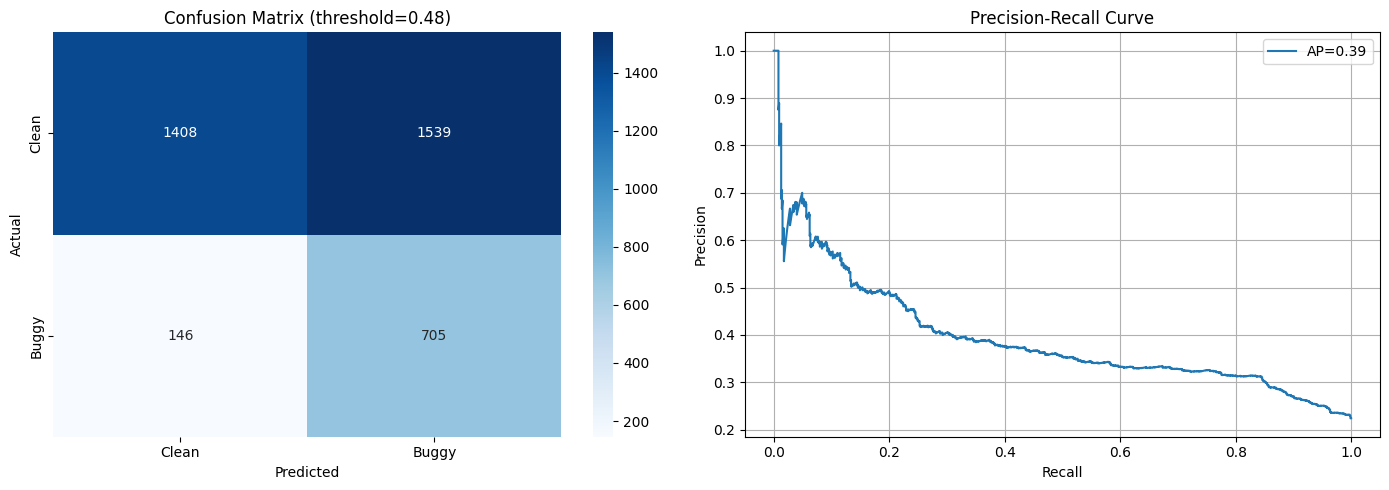

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/tmp/ipykernel_530/224871445.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_scaled, feature_names=FEATURE_NAMES, plot_type='bar', show=False)


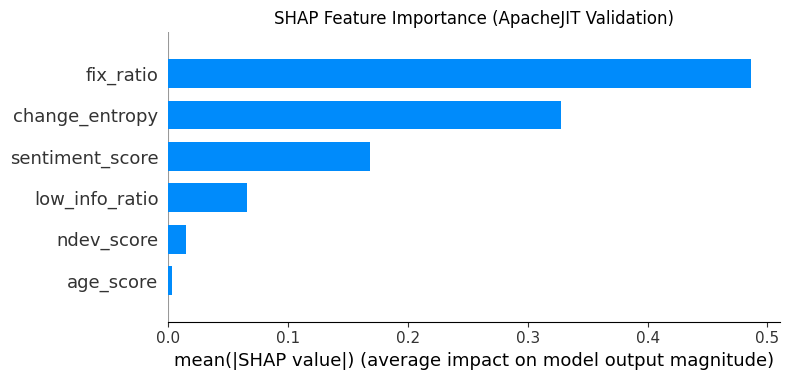

In [18]:
# ── 16. Visualizations ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

# Confusion matrix
cm = confusion_matrix(y_val_apache, y_pred_opt)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Clean', 'Buggy'], yticklabels=['Clean', 'Buggy'])
axes[0].set_title(f'Confusion Matrix (threshold={best_thresh:.2f})')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_val_apache, y_scores)
ap = average_precision_score(y_val_apache, y_scores)
axes[1].plot(recall, precision, label=f'AP={ap:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

# SHAP feature importance
explainer   = shap.LinearExplainer(risk_model, X_train_scaled, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_val_scaled)
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_val_scaled, feature_names=FEATURE_NAMES, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (ApacheJIT Validation)')
plt.tight_layout(); plt.show()

In [19]:
# ── 15. Download trained models back locally (optional) ───────────────────────
# Run this if you want to download the trained artifacts to your local machine.
# Otherwise, gomi.py will pull them from HuggingFace automatically at runtime
# via GOMI_SENTIMENT_MODEL_REPO and GOMI_RISK_MODEL_REPO in your .env.

# from google.colab import files
# import shutil

# # Zip the sentiment model
# shutil.make_archive('distilbert_sentiment', 'zip', 'models/distilbert_sentiment')
# files.download('distilbert_sentiment.zip')

# # Download risk model files individually
# files.download(RISK_MODEL_PATH)
# files.download(SHAP_BG_PATH)
# print('Downloads started.')